# Tutorial 1/3 : Forward Problem and the Clean-Data Inverse
### Why you can't just differentiate noisy data -- Part 1

**Series overview.** A uniformly heated rod, $-\alpha T''=q$. We measure $T(x)$ and want $\\alpha$.
The naive recipe $\alpha=-q/T''$ works beautifully on *clean* data and collapses on *noisy* data.
This series shows why, and what to do instead.

| Tutorial | Question | Answer in one line |
|---|---|---|
| **1 (this one)** | Does the finite-difference inverse work at all? | Yes on clean data, to ~$10^{-14}$. |
| 2 | What breaks with noise? | $\sqrt6\sigma/\Delta x^2$ noise blow-up; finer grids are worse. |
| 3 | Why and what works? | Differentiation is a high-pass amplifier; fit all data at once. |

**Learning goals (Part 1).** After this notebook you can:
1. Write the exact forward solution and both exact inverse formulas.
2. Implement the central-difference inverse and explain the "sag" picture.
3. Explain why the clean-data error is round-off (~$10^{-14}$), not truncation.




## 1. The problem

**Setting.** A rod of length $L$ with fixed end temperatures and a known, uniform heat source $q$:

$$
-\alpha\,T''(x) = q,\qquad 0\le x\le L,\qquad T(0)=T_0,\quad T(L)=T_L .
$$

**Forward vs. inverse**

```
Forward :   alpha  --(solve the PDE)-->  T(x)                       stable, easy
Inverse :   T(x)   --(differentiate twice, then divide)-->  alpha   unstable
```

In the **inverse problem** we are given measured temperatures and the source $q$, and must recover $\alpha$.

**Test case used throughout**

| Symbol | Value | Meaning |
|---|---|---|
| $L$ | 1 | rod length |
| $q$ | 1 | known heat source |
| $T_0 = T_L$ | 0 | boundary temperatures |
| $\alpha_{\rm true}$ | 0.1 | the unknown we pretend not to know |

We generate the "measurements" synthetically from the exact solution and then add noise. This lets us compare every estimate against the truth.

> **Why do we need $q$?** Without a source, $-\alpha T''=0$ gives $T''=0$, a straight line that contains no information about $\alpha$ (any $\alpha$ gives the same $T$). The source makes the temperature profile depend on $\alpha$, so the problem becomes *identifiable*.

## 2. Setup (self-contained — everything this tutorial needs)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.titlesize": 12,
})

# Problem parameters (same in all three tutorials of this series)
L = 1.0
q = 1.0
T0 = 0.0
TL = 0.0
alpha_true = 0.1

Txx_true = -q / alpha_true   # exact (constant) curvature we hope to recover

print(f"L = {L}, q = {q}, T0 = {T0}, TL = {TL}")
print(f"True alpha = {alpha_true}   ->   true T'' = {Txx_true}")


def analytical_temperature(x, alpha, L=1.0, q=1.0, T0=0.0, TL=0.0):
    # Exact solution of -alpha*T'' = q with Dirichlet boundary conditions.
    return T0 + (TL - T0) * x / L + (q / (2 * alpha)) * x * (L - x)


def fdm_second_derivative(T, dx):
    return (T[2:] - 2 * T[1:-1] + T[:-2]) / dx**2


def inverse_alpha_fdm(T, dx, q=1.0):
    Txx = fdm_second_derivative(T, dx)
    return -q / Txx, Txx


def add_noise(T, relative_noise, seed=42):
    rng = np.random.default_rng(seed)
    sigma = relative_noise * np.max(np.abs(T))
    return T + rng.normal(0.0, sigma, T.shape), sigma


L = 1.0, q = 1.0, T0 = 0.0, TL = 0.0
True alpha = 0.1   ->   true T'' = -10.0


## 3. The exact solution (forward) and the exact inverse

### 3.1 Forward solution: from $\alpha$ to $T(x)$

Rearrange $-\alpha T''=q$ to $T''=-q/\alpha$, which is a constant. Integrating twice gives a parabola:

$$
T(x) = -\frac{q}{2\alpha}x^2 + C_1 x + C_2 .
$$

The two boundary conditions fix $C_1, C_2$:

$$
\boxed{T(x)=T_0+\frac{T_L-T_0}{L}\,x+\frac{q}{2\alpha}\,x(L-x)}
\qquad\xrightarrow{\;T_0=T_L=0\;}\qquad
T(x)=\frac{q}{2\alpha}\,x(L-x).
$$

For our test case, $T(x)=5\,x(1-x)$ with peak $T_{\max}=1.25$ at $x=0.5$.

### 3.2 Inverse solution: from $T(x)$ to $\alpha$

Solving $-\alpha T''=q$ for $\alpha$:

$$
\boxed{\alpha = -\frac{q}{T''}}
$$

Because we know the *shape* of the solution, there is a second, equivalent formula that uses $T$ itself and **no derivative**:

$$
\alpha = \frac{q\,x(L-x)}{2\,T(x)} .
$$

With exact data both recover $\alpha_{\rm true}$ exactly. Keep the second formula in mind; it comes back in Section 11.

T_max    = 1.250000   (expected 1.25)
x(T_max) = 0.500000   (expected 0.5)


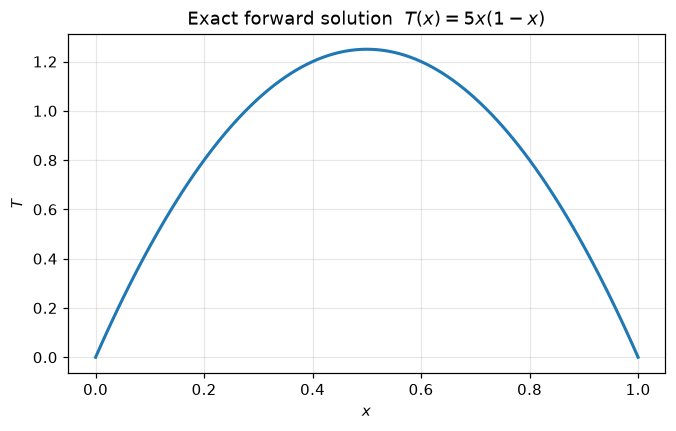

In [2]:
x = np.linspace(0.0, L, 101)
T_true = analytical_temperature(x, alpha_true, L, q, T0, TL)

print(f"T_max    = {T_true.max():.6f}   (expected 1.25)")
print(f"x(T_max) = {x[np.argmax(T_true)]:.6f}   (expected 0.5)")

plt.figure(figsize=(7, 4))
plt.plot(x, T_true, lw=2)
plt.xlabel("$x$"); plt.ylabel("$T$")
plt.title("Exact forward solution  $T(x)=5x(1-x)$")
plt.show()

In [3]:
# Exact inverse using the derivative-free formula (interior points only; T=0 at the ends)
inner = (x > 0) & (x < L)
alpha_exact_inverse = q * x[inner] * (L - x[inner]) / (2 * T_true[inner])

print("Exact inverse from exact data:")
print(f"  mean = {alpha_exact_inverse.mean():.12f}")
print(f"  std  = {alpha_exact_inverse.std():.2e}")
print(f"  true = {alpha_true:.12f}")

Exact inverse from exact data:
  mean = 0.100000000000
  std  = 1.23e-17
  true = 0.100000000000


## 4. The finite-difference inverse on clean data

In practice we only have temperatures on a grid $x_i = i\,\Delta x$, so we approximate $T''$ with the **central difference**:

$$
T''(x_i)\approx \frac{T_{i+1}-2T_i+T_{i-1}}{\Delta x^2}
\qquad\Longrightarrow\qquad
\boxed{\alpha_i^{\rm FDM} = -\frac{q\,\Delta x^2}{T_{i+1}-2T_i+T_{i-1}}}
$$

**What does the stencil measure?** Note that $T_{i+1}-2T_i+T_{i-1} = 2\big(\text{average of the two neighbours} - T_i\big)$. It asks: *how far does the middle point sit below (or above) the straight line through its neighbours?* That small "sag" is the curvature, and it is **tiny** because $\Delta x$ is small. Remember this, it is the heart of the problem.

On clean data this works essentially perfectly.

In [4]:
dx = x[1] - x[0]
alpha_clean, Txx_clean = inverse_alpha_fdm(T_true, dx, q)

print(f"dx = {dx}")
print(f"mean alpha        = {alpha_clean.mean():.12f}")
print(f"max |alpha error| = {np.max(np.abs(alpha_clean - alpha_true)):.2e}")
print(f"\nThe 'sag' we must detect at each point: |T''|*dx^2 = {abs(Txx_true)*dx**2:.1e}")

dx = 0.01
mean alpha        = 0.100000000000
max |alpha error| = 5.54e-14

The 'sag' we must detect at each point: |T''|*dx^2 = 1.0e-03


> **Why is the error ~$10^{-14}$ and not zero?** For a quadratic $T$ the central difference is *exact* (its truncation error involves $T''''$, which is zero here). The leftover $10^{-14}$ is floating-point round-off. We will see in Section 9 that even this round-off follows the same amplification law as measurement noise.

## What you should take away (Part 1)

- The forward map $\alpha \to T$ is stable; the exact inverse needs $T''$.
- The 3-point stencil measures a tiny "sag" $|T''|\Delta x^2$ (~$10^{-3}$ here).
- On clean data the inverse is essentially perfect; the $10^{-14}$ leftover is floating-point round-off, *not* a stencil bug.

**Next:** Part 2 adds just 1% measurement noise — the data still *look* fine, but the inverse collapses.

### Exercise 1.1 (5 min)
Change `alpha_true` to 0.2 in the setup cell, re-run, and confirm `T_max` and the clean FDM error.
Why does the stencil stay exact for any $\alpha$? (Hint: what is $T^{(4)}$ for a parabola?)
